In [1]:
""" 
IMPORTS
"""
import os
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, pearsonr, spearmanr

# --Machine learning and statistics
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore


""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'

def filter_sequences(all_sequences, min_sessions=1):
    """
    min_sessions : int
        Minimum number of sessions a mouse must have to be kept.
        The proficient dataset has many sessions per mouse, so 3 makes sense there.
        The single-timepoint training datasets used here (first session, last
        training session) have exactly ONE session per mouse, so min_sessions must
        be 1 or every mouse is dropped and design_df comes out empty.
    """
    print(str(len(all_sequences.mouse_name.unique())) + str(' mice in total'))
    print(str(len(all_sequences.session.unique())) + str(' sessions in total'))

    # FIX: Use drop=True to avoid creating 'index' column
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(str(len(all_sequences['session'].unique())) + str(' sessions after removing bad sessions'))

    # Filter out mice without enough sessions
    session_count = all_sequences[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
    multi_sess_mice = session_count.loc[session_count['session'] >= min_sessions, 'mouse_name']

    # FIX: Use drop=True here too
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(str(len(multi_sess_mice)) + ' mice with at least ' + str(min_sessions) + ' session(s)')
    print(str(len(all_sequences['session'].unique())) + str(' remaining sessions'))

    # Validation
    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    print("✓ Data preparation validated")
    return all_sequences

def binarize(use_sequences, n_paw_states=8, 
             keep_paw=True, keep_whisk=True, keep_lick=False):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    Automatically infers feature dimensions based on the requested combination.
    
    Parameters:
    -----------
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    keep_paw : bool
        Whether to keep the binarized paw states (automatically drops reference state 1).
    keep_whisk : bool
        Whether to keep the whisking state.
    keep_lick : bool
        Whether to keep the licking state.
        
    Returns:
    --------
    binarized_reduced : np.ndarray
        The filtered sequence array.
    n_out_features : int
        The number of features per timestep in the final output array.
    """
    if not (keep_paw or keep_whisk or keep_lick):
        raise ValueError("At least one feature type (paw, whisk, or lick) must be kept.")

    # The raw decoding always requires n_paw_states + 1 (whisk) + 1 (lick) columns
    n_raw_features_per_step = n_paw_states + 2 

    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_raw_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        
        start_col = t * n_raw_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_raw_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Determine which columns to keep within a single timestep block
    cols_to_keep_base = []
    if keep_paw:
        # Keep all paw states EXCEPT index 1 (Paw State 2)
        cols_to_keep_base.extend([i for i in range(n_paw_states) if i != 1])
    if keep_whisk:
        cols_to_keep_base.append(n_paw_states)
    if keep_lick:
        cols_to_keep_base.append(n_paw_states + 1)

    n_out_features = len(cols_to_keep_base)

    # Expand these base indices across all timesteps
    all_cols_to_keep = []
    for t in range(timesteps):
        offset = t * n_raw_features_per_step
        all_cols_to_keep.extend([offset + c for c in cols_to_keep_base])
        
    # Slice the array to keep only the requested features
    binarized_reduced = binarized[:, all_cols_to_keep]
    
    return binarized_reduced


def build_design_matrix(filename, exclude_sessions, keep_paw, keep_whisk, keep_lick, min_sessions=1):
    
    # Load data
    all_sequences = pd.read_parquet(filename)
    all_sequences['session'] = all_sequences['sample'].str[:36]
    # min_sessions=1 keeps the prob_sessions exclusion but does NOT require several
    # sessions per mouse (these datasets have one session per mouse)
    all_sequences = filter_sequences(all_sequences, min_sessions=min_sessions)
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(exclude_sessions)]

    # if 'syllables' in filename or 'sequences' in filename:     
    design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
    # Remove any spurious 'index' column created by reset_index
    if 'index' in design_df.columns:
        design_df = design_df.drop(columns=['index'])
    design_df = design_df.sort_values(by='session')

    # Validate
    assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
    print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

    epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
    use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

    # Validate alignment
    assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

    # --- PARAMETERS ---
    use_format = binarize(use_sequences, n_paw_states=8)

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    session_syllables = pd.DataFrame(use_format)
    session_syllables['session'] = design_df['session'].values
    # NaN bins (frames with no tracking) are ignored rather than propagated, so a
    # single bad trial cannot NaN out a whole session-level feature
    session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

    # Any feature still all-NaN for some session would break PCA -> drop those columns
    n_bad_cols = int(session_syllables.isna().any(axis=0).sum())
    if n_bad_cols > 0:
        print(f"!! dropping {n_bad_cols} feature columns that are NaN for at least one session")
        session_syllables = session_syllables.loc[:, ~session_syllables.isna().any(axis=0)]

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])

    print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
    print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")
    
    # design_df = session_syllables.drop_duplicates()
    design_df = design_df[['mouse_name', 'session']].drop_duplicates()
    print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features ")

    return session_syllables, design_df, mouse_names_list


def dim_red(session_syllables, n_component):
    """
    Diagnostic / stand-alone reduction. Reports how many PCs explain `threshold` of
    the variance and returns the projection truncated to n_component.

    NOTE: regression_cv below does NOT use this -- it refits PCA inside each CV fold
    so held-out sessions never contribute to the components.
    """
    all_features = session_syllables.copy()

    # PCA -- fit as many components as the data supports
    n_max = np.min([np.shape(np.array(all_features))[0], np.shape(np.array(all_features))[1]])
    pca = PCA(n_max)
    X_pca = pca.fit_transform(np.array(all_features))

    # Explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    threshold = 0.6
    min_components = np.where(cumulative_variance > threshold)[0][0]
    # min_components = 20
    print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

    # # Plot explained variance
    # plt.figure(figsize=(8, 5))
    # plt.plot(range(1, n_max+1), explained_variance_ratio, marker='o', label='Individual')
    # plt.plot(range(1, n_max+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
    # plt.hlines(threshold, 0, 250, 'black', 'dashed')
    # plt.vlines(min_components, 0, 1, 'black', 'dashed')
    # plt.xlabel("Number of Principal Components")
    # plt.ylabel("Variance Explained")
    # plt.title("Explained Variance by PCA")
    # plt.show()

    # FIX: slice to the REQUESTED number of components. This line used to read
    # X_pca[:, :n_components], where n_components had been overwritten above by
    # n_max -- so every point of the dimensionality sweep used ALL components.
    mat = np.array(X_pca[:, :n_component])

    scaler = StandardScaler()
    norm_pop = scaler.fit_transform(mat.copy())
    
    return norm_pop, min_components


def grouped_kfold_splits(groups, n_splits, rng):
    """
    K-fold splits that keep every session of a mouse on the same side of the split.
    The target (a mouse's LD score) is constant across that mouse's sessions, so a
    plain KFold would put the very same value in train and test -- leakage.
    Groups are permuted with `rng`, so repeats give genuinely different partitions.
    """
    uniq = np.unique(groups)
    permuted = rng.permutation(uniq)
    for fold_groups in np.array_split(permuted, n_splits):
        test_mask = np.isin(groups, fold_groups)
        yield np.where(~test_mask)[0], np.where(test_mask)[0]


def score_predictions(y_mouse, pred_mouse):
    """
    All the ways of scoring one set of mouse-level out-of-fold predictions.

    Why several: a correlation is invariant to scale and offset, R2 is not. They are
    related exactly by

        R2 = 2*r*k - k**2 - b**2
        k = sd(pred)/sd(y)                 "amplitude"  -- how wide the predictions swing
        b = (mean(pred) - mean(y))/sd(y)   "bias"       -- systematic offset

    so a model can order mice correctly (good r) while its predicted VALUES are
    useless (very negative R2). Maximising over k gives k = r, i.e. the best R2 any
    rescaling could buy is r**2 - b**2. Reporting r without k and b hides that.
    """
    r, r_p = pearsonr(y_mouse, pred_mouse)
    rho, rho_p = spearmanr(y_mouse, pred_mouse)
    k = pred_mouse.std() / y_mouse.std()
    b = (pred_mouse.mean() - y_mouse.mean()) / y_mouse.std()
    # NOTE on the parametric p-values: they test r == 0 assuming independent
    # observations and a null centred on zero. Under mouse-grouped CV with a
    # per-mouse-constant target NEITHER holds -- the null is centred well below 0
    # (see permutation_null). Treat them as descriptive; the permutation p is the
    # one to quote.
    return dict(pooled_r2=r2_score(y_mouse, pred_mouse),
                pearson_r=r, pearson_p=r_p,
                spearman_rho=rho, spearman_p=rho_p,
                amplitude_k=k, bias_b=b,
                rescale_ceiling=r**2 - b**2)


def regression_cv(X_raw, continuous_y, groups, n_pcs, n_splits=5, n_repeats=20,
                  alpha=1.0, tune_alpha=False, alpha_c_grid=None, inner_splits=3,
                  stratify_folds=False, whiten_pcs=False, verbose=True):
    """
    Predicts a continuous variable (an LD score) from session-level behavioural
    features, using repeated MOUSE-GROUPED K-Fold cross-validation.

    Parameters:
    - X_raw: session-level feature matrix (sessions x features), NOT pre-reduced
    - continuous_y: continuous target per session (sessions,)
    - groups: mouse name per session; splits and the null both respect these
    - n_pcs: number of PCs to keep (PCA is refit on the training fold only)
    - n_splits / n_repeats: outer grouped K-fold, repeated
    - alpha: Ridge L2 penalty when tune_alpha is False
    - tune_alpha: choose alpha by an INNER mouse-grouped CV on each training fold.
      alpha=1.0 fixed is badly overfit here (it makes the predictions swing far too
      wide, i.e. k >> r, which is what drives R2 negative).
    - stratify_folds: balance the folds on target quantile bins. The plain grouped
      split leaves the training mean offset from the held-out fold's mean, which
      biases both R2 and the correlation downwards.

    Returns a dict of metrics, or None if n_pcs exceeds what a training fold supports.
    """
    X = np.asarray(X_raw, dtype=float)
    y = np.asarray(continuous_y, dtype=float)
    groups = np.asarray(groups)
    if alpha_c_grid is None:
        # SCALE-FREE shrinkage constants. alpha itself is meaningless across folds:
        # ridge shrinkage is d^2/(d^2+alpha) and d^2 scales with n_train, so a fixed
        # alpha means different shrinkage for a 30-session and a 93-session fold.
        # Here alpha = c * trace(Z'Z)/n_pcs, so the same c means the same shrinkage.
        alpha_c_grid = np.logspace(-3, 2, 11)

    uniq_groups = np.unique(groups)

    # PCA cannot return more components than min(n_train_samples, n_features), and
    # the training folds are smaller than the full dataset.
    min_train_sessions = int(np.min([
        np.sum(~np.isin(groups, fold_groups))
        for fold_groups in np.array_split(uniq_groups, n_splits)
    ]))
    max_pcs = int(np.min([min_train_sessions, X.shape[1]]))
    if n_pcs > max_pcs:
        if verbose:
            print(f"!! skipping n_pcs={n_pcs}: only {max_pcs} components available "
                  f"(smallest training fold has {min_train_sessions} sessions)")
        return None

    group_target = {g: y[groups == g][0] for g in uniq_groups}

    within_fold_r2 = []
    oof_predictions = np.zeros(len(y))
    oof_counts = np.zeros(len(y))
    chosen_alphas = []

    def make_model(a=None):
        # PCA (and optional whitening) are fit on the TRAINING fold only.
        # whiten_pcs=True z-scores the PC scores, which EQUALISES every PC's variance
        # and so destroys the spectral regularisation PCA gives for free: PC20 is
        # then trusted as much as PC1, and only the hard truncation at n_pcs
        # suppresses noise directions. whiten_pcs=False leaves d^2 = n*lambda_j, so
        # ridge shrinks low-variance PCs more. That is usually what you want -- but
        # LD1 comes from an LDA (between/within ratio), which is under no obligation
        # to align with high-variance PCs, so it is an empirical question.
        steps = [('pca', CappedPCA(n_pcs))]
        if whiten_pcs:
            steps.append(('scale', StandardScaler()))
        steps.append(('ridge', Ridge(alpha=alpha if a is None else a)))
        return Pipeline(steps)

    def fold_alpha_grid(X_train):
        """Scale-free constants -> actual alphas for THIS fold:
        alpha = c * trace(Z'Z)/n_pcs = c * n_train * mean(PC variance).
        With whiten_pcs=True this reduces to c * n_train."""
        Z = CappedPCA(n_pcs).fit_transform(X_train)
        scale = 1.0 if whiten_pcs else float(np.mean(np.var(Z, axis=0)))
        return np.asarray(alpha_c_grid) * X_train.shape[0] * scale

    for repeat in range(n_repeats):
        rng = np.random.default_rng(seed=repeat)
        splitter = (stratified_grouped_splits if stratify_folds else grouped_kfold_splits)
        for train_idx, test_idx in splitter(y, groups, n_splits, rng):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            if tune_alpha:
                gs = GridSearchCV(make_model(),
                                  {'ridge__alpha': fold_alpha_grid(X_train)},
                                  cv=GroupKFold(n_splits=inner_splits), scoring='r2')
                gs.fit(X_train, y_train, groups=groups[train_idx])
                model = gs.best_estimator_
                chosen_alphas.append(gs.best_params_['ridge__alpha'])
            else:
                model = make_model().fit(X_train, y_train)

            pred = np.asarray(model.predict(X_test)).ravel()
            # Per-fold R2 uses THIS fold's own mean as its baseline. With only a
            # handful of held-out mice that denominator is tiny and noisy, so the
            # average of these is biased far downwards -- kept only as a diagnostic.
            within_fold_r2.append(r2_score(y_test, pred))
            oof_predictions[test_idx] += pred
            oof_counts[test_idx] += 1

    pred_session = oof_predictions / np.maximum(oof_counts, 1)

    # One point per mouse: sessions of a mouse share a target, so scoring over
    # sessions would be pseudo-replication.
    y_mouse = np.array([y[groups == g][0] for g in uniq_groups])
    pred_mouse = np.array([pred_session[groups == g].mean() for g in uniq_groups])

    out = score_predictions(y_mouse, pred_mouse)
    out.update(within_fold_r2=float(np.mean(within_fold_r2)),
               within_fold_r2_sem=float(sem(within_fold_r2)),
               n_mice=len(uniq_groups), n_pcs=n_pcs,
               y_mouse=y_mouse, pred_mouse=pred_mouse,
               median_alpha=float(np.median(chosen_alphas)) if chosen_alphas else alpha)

    if verbose:
        print(f"  n_pcs={n_pcs:3d} | Spearman rho={out['spearman_rho']:+.3f} "
              f"Pearson r={out['pearson_r']:+.3f} | pooled R2={out['pooled_r2']:+.3f} "
              f"(within-fold R2={out['within_fold_r2']:+.3f}) | "
              f"k={out['amplitude_k']:.2f} b={out['bias_b']:+.2f}")
    return out


def stratified_grouped_splits(y, groups, n_splits, rng, n_bins=4):
    """
    Grouped folds balanced on target quantile bins, so the training mean is not
    systematically offset from the held-out fold's mean.
    """
    edges = np.quantile(y, np.linspace(0, 1, n_bins + 1)[1:-1])
    strat = np.digitize(y, edges)
    seed = int(rng.integers(0, 2**31 - 1))
    sgk = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(sgk.split(np.zeros((len(y), 1)), strat, groups))


def permutation_null(X, y, groups, n_pcs, n_perm=200, **kwargs):
    """
    Re-runs the whole CV with the per-mouse targets permuted, giving a null
    distribution for every metric.

    This is not optional here. Under mouse-grouped CV with a target that is constant
    within a mouse, holding out a set of mice leaves the training set biased away
    from them, so the null for the correlation is NOT 0 and the null for R2 is NOT 0
    -- and how far off they are depends on how hard the model shrinks. Comparing two
    models against a fixed reference line is therefore invalid.
    """
    keys = ['pooled_r2', 'pearson_r', 'spearman_rho']
    null = {k: [] for k in keys}
    for i in range(n_perm):
        rng = np.random.default_rng(10_000 + i)
        y_perm = permute_within_mice(y, groups, rng)
        res = regression_cv(X, y_perm, groups, n_pcs, verbose=False, **kwargs)
        if res is None:
            return None
        for k in keys:
            null[k].append(res[k])
    return {k: np.array(v) for k, v in null.items()}


def permute_within_mice(y, groups, rng):
    """Reassign each mouse's target to another mouse, keeping its sessions consistent."""
    mice = np.unique(groups)
    target = {g: y[groups == g][0] for g in mice}
    mapping = dict(zip(mice, rng.permutation(mice)))
    return np.array([target[mapping[g]] for g in groups])


def perm_p(observed, null_values):
    """One-sided permutation p-value. Floor is 1/(n_perm+1) -- watch it."""
    null_values = np.asarray(null_values)
    return (np.sum(null_values >= observed) + 1) / (len(null_values) + 1)


class CappedPCA(BaseEstimator, TransformerMixin):
    """
    PCA that clips n_components to what the training fold allows. Needed because
    nested CV makes the inner training folds smaller still, and plain PCA raises if
    n_components > min(n_samples, n_features).
    """
    def __init__(self, n_components=10, random_state=0):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        k = int(min(self.n_components, X.shape[0] - 1, X.shape[1]))
        self.pca_ = PCA(n_components=max(k, 1), random_state=self.random_state).fit(X)
        self.n_components_ = self.pca_.n_components_
        return self

    def transform(self, X):
        return self.pca_.transform(X)


In [7]:
""" SESSION EXCLUSIONS -- from the curated QC sheet """
from session_filters import exclusions_by_timepoint
QC_STRICTNESS = 'filtered_out'      # or 'filtered_out_and_revise'
_excl = exclusions_by_timepoint(QC_STRICTNESS)
prob_sessions = _excl['Proficient']
# datasets are listed Early, Late, Pre-rec -- keep this aligned with `datasets`
exclude_sessions = [_excl['Early'], _excl['Late'], _excl['Pre-rec']]
print(f"exclusions ({QC_STRICTNESS}): " + ", ".join(f"{k} {len(v)}" for k,v in _excl.items()))

n_paw_states = 8
datasets = [
    base_path + 'training/' + 'paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
    base_path + 'training/' + 'paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
    base_path + 'training/' + 'paw_wheel_biased_8_k_10_bin_syllables_04-09-2026',
]


n_components = np.arange(5, 30, 5)
n_components = [5, 10, 15, 20, 25]
n_components = [3, 5, 9, 11, 13, 15, 17, 20, 25]
n_components = [9, 13, 17, 20]

lda_df = pd.read_pickle('/home/ines/repositories/representation_learning_variability/paper-individuality/' + 'clustering/data_files/mouse_LDA_5_bins_cut19-08-2026')
lda_to_predict = 0

# --- CV settings ---
n_splits = 2
n_repeats = 20
TUNE_ALPHA = False       # choose Ridge alpha by inner grouped CV (alpha=1.0 is overfit)

# Which behavioural feature families to build the design matrix from
KEEP_PAW, KEEP_WHISK, KEEP_LICK = True, True, True
STRATIFY_FOLDS = True   # balance folds on target quantile bins

# Sweep results. Spearman rho is the PRIMARY statistic: the claim these data can
# support is ordinal ("where does this mouse sit on LD1"), not calibrated prediction.
spearman = np.zeros((len(datasets), len(n_components))) * np.nan
pearson  = np.zeros((len(datasets), len(n_components))) * np.nan
# Pooled out-of-fold R2 over all mice -- the honest version. within_fold_r2 is the
# mean of per-fold R2s (each against its own ~8-mouse fold mean), kept only to show
# how badly biased downwards that estimator is.
pooled_r2 = np.zeros((len(datasets), len(n_components))) * np.nan
within_fold_r2 = np.zeros((len(datasets), len(n_components))) * np.nan
# Calibration diagnostics: k = sd(pred)/sd(y), b = (mean pred - mean y)/sd(y).
# R2 = 2*r*k - k^2 - b^2, so these say WHY R2 is negative.
amp_k = np.zeros((len(datasets), len(n_components))) * np.nan
bias_b = np.zeros((len(datasets), len(n_components))) * np.nan

n_mice_per_dataset = np.zeros(len(datasets)) * np.nan
dataset_cache = {}
best_result = {}

for d, dataset in enumerate(datasets):
    print(d, dataset)

    if not os.path.exists(dataset):
        print(f'!! skipping missing dataset: {dataset}')
        continue

    # min_sessions=1: these are single-timepoint datasets with ~1 session per mouse
    session_syllables, design_df, mouse_names_list = build_design_matrix(
        dataset, exclude_sessions[d],
        keep_paw=KEEP_PAW, keep_whisk=KEEP_WHISK, keep_lick=KEEP_LICK,
        min_sessions=1)

    """ TARGET: the mouse's LD score, averaged over its proficient sessions """
    lda_per_mouse = (lda_df.loc[lda_df['mouse_name'].isin(mouse_names_list)]
                     [[lda_to_predict, 'mouse_name']]
                     .groupby('mouse_name').mean())
    lda_var = lda_per_mouse.reindex(mouse_names_list)[lda_to_predict].values

    valid = ~np.isnan(lda_var)
    if not valid.all():
        missing = np.unique(mouse_names_list[~valid])
        print(f"!! {len(missing)} mice have no LD{lda_to_predict} value, dropping "
              f"{np.sum(~valid)} sessions: {list(missing)}")
    X_all = np.asarray(session_syllables)[valid]
    y_all = lda_var[valid]
    groups_all = mouse_names_list[valid]

    # cached so the permutation-null cell below does not rebuild the design matrix
    dataset_cache[d] = dict(X=X_all, y=y_all, groups=groups_all)

    n_mice_per_dataset[d] = len(np.unique(groups_all))
    print(f"→ {X_all.shape[0]} sessions from {int(n_mice_per_dataset[d])} mice, "
          f"{X_all.shape[1]} features; LD{lda_to_predict} range "
          f"[{y_all.min():.2f}, {y_all.max():.2f}]")

    best_rho = -np.inf
    for b, n_component in enumerate(n_components):

        """ RIDGE REGRESSION, mouse-grouped CV, PCA refit inside each fold """
        res = regression_cv(X_all, y_all, groups=groups_all, n_pcs=n_component,
                            n_splits=n_splits, n_repeats=n_repeats,
                            tune_alpha=TUNE_ALPHA, stratify_folds=STRATIFY_FOLDS)
        if res is None:
            continue

        spearman[d, b] = res['spearman_rho']
        pearson[d, b] = res['pearson_r']
        pooled_r2[d, b] = res['pooled_r2']
        within_fold_r2[d, b] = res['within_fold_r2']
        amp_k[d, b] = res['amplitude_k']
        bias_b[d, b] = res['bias_b']

        if res['spearman_rho'] > best_rho:
            best_rho = res['spearman_rho']
            best_result[d] = res

    print(f"→ best Spearman rho = {best_rho:+.3f} at {best_result[d]['n_pcs']} PCs")


exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12
0 /home/ines/repositories/representation_learning_variability/paper-individuality/data/training/paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026
47 mice in total
47 sessions in total
47 sessions after removing bad sessions
47 mice with at least 1 session(s)
47 remaining sessions
✓ Data preparation validated
✓ design_df created: 8491 rows, 37 mice, 37 sessions
✓ Session aggregation complete: 37 sessions
✓ Mouse labels: {np.str_('CSHL049'): np.int64(1), np.str_('CSHL052'): np.int64(1), np.str_('CSHL053'): np.int64(1), np.str_('CSHL058'): np.int64(1), np.str_('CSHL059'): np.int64(1), np.str_('CSH_ZAD_019'): np.int64(1), np.str_('CSH_ZAD_026'): np.int64(1), np.str_('CSH_ZAD_029'): np.int64(1), np.str_('DY_009'): np.int64(1), np.str_('DY_010'): np.int64(1), np.str_('DY_011'): np.int64(1), np.str_('DY_014'): np.int64(1), np.str_('DY_016'): np.int64(1), np.str_('DY_018'): np.int64(1), np.str_('NYU-45'): np.int64(1), np.

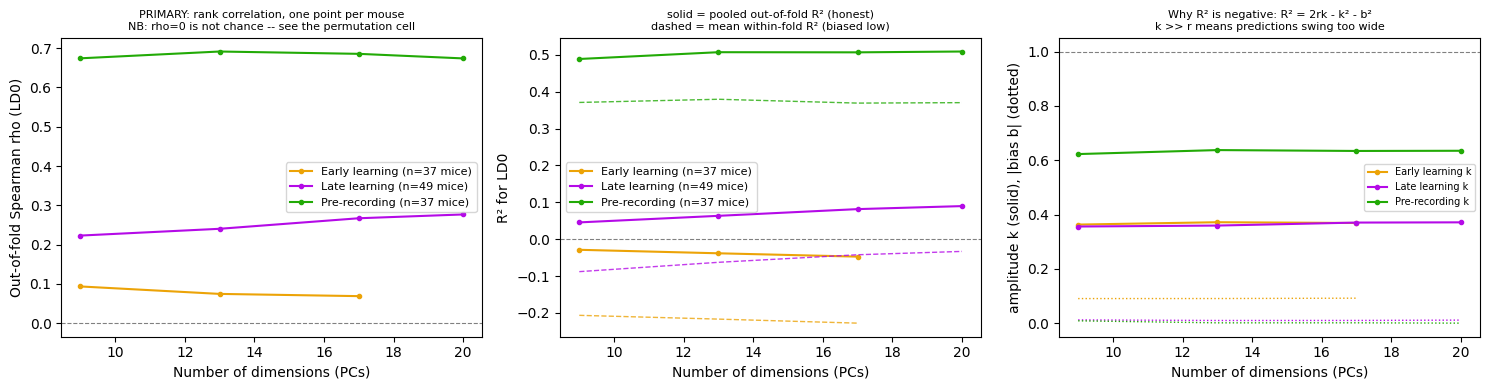

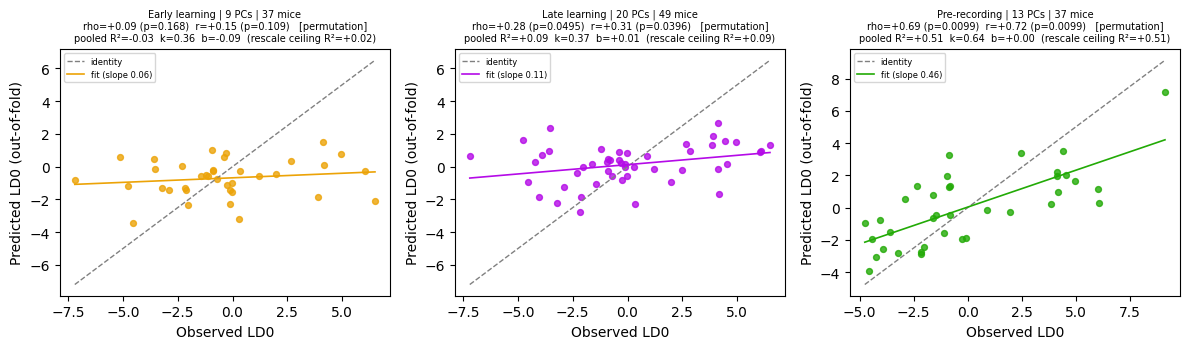

In [8]:
# --- How well is LD0 predicted, and is the prediction calibrated? ---
labels = ['Early learning', 'Late learning', 'Pre-recording']
colors = ["#ECA307", "#B40AE7", "#22AA06"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for d, dataset in enumerate(datasets):
    if np.all(np.isnan(spearman[d, :])):
        continue
    lab = f'{labels[d]} (n={int(n_mice_per_dataset[d])} mice)'

    # PRIMARY: rank correlation. The supportable claim is ordinal.
    axes[0].plot(n_components, spearman[d, :], color=colors[d], label=lab, marker='o', ms=3)

    # Pooled R2 (solid) vs the mean of within-fold R2s (dashed). The gap is an
    # artefact of averaging per-fold R2s computed against tiny fold means.
    axes[1].plot(n_components, pooled_r2[d, :], color=colors[d], label=lab, marker='o', ms=3)
    axes[1].plot(n_components, within_fold_r2[d, :], color=colors[d],
                 linestyle='dashed', linewidth=1, alpha=0.8)

    # Calibration: k should sit near r for R2 to be as good as the ranking allows.
    axes[2].plot(n_components, amp_k[d, :], color=colors[d], label=f'{labels[d]} k', marker='o', ms=3)
    axes[2].plot(n_components, np.abs(bias_b[d, :]), color=colors[d],
                 linestyle='dotted', linewidth=1)

axes[0].axhline(0, color='grey', lw=0.8, ls='dashed')
axes[0].set_xlabel('Number of dimensions (PCs)')
axes[0].set_ylabel(f'Out-of-fold Spearman rho (LD{lda_to_predict})')
axes[0].set_title('PRIMARY: rank correlation, one point per mouse\n'
                  'NB: rho=0 is not chance -- see the permutation cell', fontsize=8)
axes[0].legend(fontsize=8)

axes[1].axhline(0, color='grey', lw=0.8, ls='dashed')
axes[1].set_xlabel('Number of dimensions (PCs)')
axes[1].set_ylabel(f'R² for LD{lda_to_predict}')
axes[1].set_title('solid = pooled out-of-fold R² (honest)\n'
                  'dashed = mean within-fold R² (biased low)', fontsize=8)
axes[1].legend(fontsize=8)

axes[2].axhline(1, color='grey', lw=0.8, ls='dashed')
axes[2].set_xlabel('Number of dimensions (PCs)')
axes[2].set_ylabel('amplitude k (solid), |bias b| (dotted)')
axes[2].set_title('Why R² is negative: R² = 2rk - k² - b²\n'
                  'k >> r means predictions swing too wide', fontsize=8)
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

#%
# --- Observed vs predicted, one point per mouse, at the best rho ---
fig, axes = plt.subplots(1, len(datasets), figsize=(4 * len(datasets), 3.6), squeeze=False)
for d, dataset in enumerate(datasets):
    ax = axes[0, d]
    res = best_result.get(d)
    if res is None:
        ax.set_axis_off()
        continue
    ax.scatter(res['y_mouse'], res['pred_mouse'], color=colors[d], s=18, alpha=0.8)
    lims = [min(res['y_mouse'].min(), res['pred_mouse'].min()),
            max(res['y_mouse'].max(), res['pred_mouse'].max())]
    ax.plot(lims, lims, color='grey', linestyle='dashed', linewidth=1, label='identity')
    # A shrunk predictor (k < 1) SHOULD sit in a compressed band, so the identity
    # line is the wrong visual reference -- show the actual fit as well.
    sl, ic = np.polyfit(res['y_mouse'], res['pred_mouse'], 1)
    xs = np.array(lims)
    ax.plot(xs, sl * xs + ic, color=colors[d], linewidth=1.2, label=f'fit (slope {sl:.2f})')
    ax.legend(fontsize=6, loc='best')
    ax.set_xlabel(f'Observed LD{lda_to_predict}')
    ax.set_ylabel(f'Predicted LD{lda_to_predict} (out-of-fold)')
    # Permutation p if the null cell has been run, otherwise the parametric one.
    # The parametric p assumes a null centred at 0, which is WRONG here -- it is
    # shown only so the panel is never unlabelled.
    nr = globals().get('null_results', {}).get(d)
    if nr is not None:
        p_rho = perm_p(res['spearman_rho'], nr['spearman_rho'])
        p_r = perm_p(res['pearson_r'], nr['pearson_r'])
        p_src = 'permutation'
    else:
        p_rho, p_r = res['spearman_p'], res['pearson_p']
        p_src = 'parametric, optimistic'
    ax.set_title(f"{labels[d]} | {res['n_pcs']} PCs | {res['n_mice']} mice\n"
                 f"rho={res['spearman_rho']:+.2f} (p={p_rho:.3g})  "
                 f"r={res['pearson_r']:+.2f} (p={p_r:.3g})   [{p_src}]\n"
                 f"pooled R²={res['pooled_r2']:+.2f}  k={res['amplitude_k']:.2f}  "
                 f"b={res['bias_b']:+.2f}  (rescale ceiling R²={res['rescale_ceiling']:+.2f})",
                 fontsize=7)
plt.tight_layout()
plt.show()



Early learning: 100 permutations at 9 PCs (37 mice) ...
  p-value floor with N_PERM=100: 0.009901
  spearman_rho  observed +0.093 | null -0.095 ± 0.207 (max +0.331) | p_perm = 0.1683
  pearson_r     observed +0.153 | null -0.117 ± 0.207 (max +0.257) | p_perm = 0.1089
  pooled_r2     observed -0.029 | null -0.133 ± 0.090 (max +0.054) | p_perm = 0.1584

Late learning: 100 permutations at 20 PCs (49 mice) ...
  p-value floor with N_PERM=100: 0.009901
  spearman_rho  observed +0.277 | null -0.068 ± 0.201 (max +0.385) | p_perm = 0.0495
  pearson_r     observed +0.307 | null -0.071 ± 0.198 (max +0.369) | p_perm = 0.0396
  pooled_r2     observed +0.090 | null -0.152 ± 0.109 (max +0.123) | p_perm = 0.0297

Pre-recording: 100 permutations at 17 PCs (37 mice) ...
  p-value floor with N_PERM=100: 0.009901
  spearman_rho  observed +0.709 | null -0.183 ± 0.249 (max +0.429) | p_perm = 0.009901
  pearson_r     observed +0.742 | null -0.192 ± 0.240 (max +0.405) | p_perm = 0.009901
  pooled_r2     obs

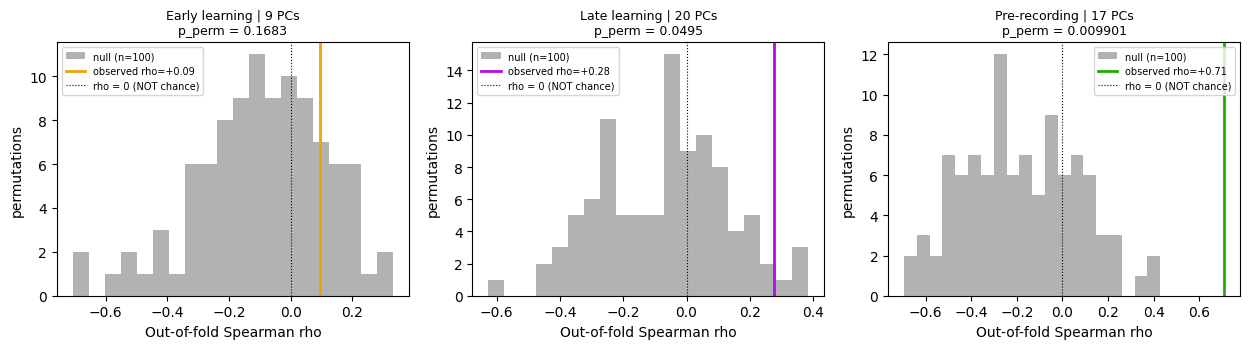

In [4]:
#%%
# ============================================================================
# PERMUTATION NULLS -- run this before believing any number above.
# ----------------------------------------------------------------------------
# Under mouse-grouped CV with a per-mouse-constant target, holding out a set of
# mice leaves the training set biased away from them. So rho=0 and R2=0 are NOT
# chance, and how far off they are depends on how hard the model shrinks -- which
# means models cannot be compared against a shared reference line either.
#
# Slow: N_PERM re-runs of the whole CV per dataset. Start with 100.
# The p-value floor is 1/(N_PERM+1), so N_PERM=100 cannot go below 0.0099.
# ============================================================================
N_PERM = 100

null_results = {}
for d in range(len(datasets)):
    res = best_result.get(d)
    if res is None or d not in dataset_cache:
        continue
    X, y, groups = dataset_cache[d]['X'], dataset_cache[d]['y'], dataset_cache[d]['groups']
    n_pcs = res['n_pcs']

    print(f"\n{labels[d]}: {N_PERM} permutations at {n_pcs} PCs "
          f"({int(n_mice_per_dataset[d])} mice) ...", flush=True)
    null = permutation_null(X, y, groups, n_pcs, n_perm=N_PERM,
                            n_splits=n_splits, n_repeats=n_repeats,
                            tune_alpha=TUNE_ALPHA, stratify_folds=STRATIFY_FOLDS)
    if null is None:
        continue
    null_results[d] = null

    print(f"  p-value floor with N_PERM={N_PERM}: {1/(N_PERM+1):.4g}")
    for key, obs in [('spearman_rho', res['spearman_rho']),
                     ('pearson_r', res['pearson_r']),
                     ('pooled_r2', res['pooled_r2'])]:
        nd = null[key]
        print(f"  {key:13s} observed {obs:+.3f} | null {nd.mean():+.3f} ± {nd.std():.3f} "
              f"(max {nd.max():+.3f}) | p_perm = {perm_p(obs, nd):.4g}")

#%%
# --- Observed statistic against its own null distribution ---
fig, axes = plt.subplots(1, len(null_results) or 1, figsize=(4.2 * (len(null_results) or 1), 3.6),
                         squeeze=False)
for ax_i, (d, null) in enumerate(sorted(null_results.items())):
    ax = axes[0, ax_i]
    res = best_result[d]
    ax.hist(null['spearman_rho'], bins=20, color='grey', alpha=0.6,
            label=f'null (n={len(null["spearman_rho"])})')
    ax.axvline(res['spearman_rho'], color=colors[d], lw=2,
               label=f"observed rho={res['spearman_rho']:+.2f}")
    ax.axvline(0, color='black', lw=0.8, ls='dotted', label='rho = 0 (NOT chance)')
    ax.set_xlabel('Out-of-fold Spearman rho')
    ax.set_ylabel('permutations')
    ax.set_title(f"{labels[d]} | {res['n_pcs']} PCs\n"
                 f"p_perm = {perm_p(res['spearman_rho'], null['spearman_rho']):.4g}", fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()
